# Train Commutative CNN

This notebook intentionally keeps orchestration thin. Split preparation, fitting, reporting, plotting, and persistence are delegated to shared utilities in `src.ml`.


In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_estimator_on_experiment,
    persist_experiment_artifacts,
    plot_holdout_branch_embedding_projections,
    plot_training_history,
    prepare_multitask_experiment_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import build_tensor_embedding_2d, load_labeled_tensor_dataset, plot_tensor_embedding_2d

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


In [2]:
from src.ml import CommutativeCNNClassifier, CommutativeCNNConfig


In [3]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
print(dataset_artifact_path.name)
experiment_output_dir = Path("artifacts/nb7_commutative_cnn")
persist_artifacts = True

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 6
rotation_range_degrees = 12.0

model_config = CommutativeCNNConfig(
    spatial_conv_channels=(8, 12, 16),
    spatial_kernel_size_z=(1, 1, 1),
    spatial_kernel_size_xy=(5, 3, 3),
    spatial_stride_z=(1, 1, 1),
    spatial_stride_xy=(1, 1, 1),
    spatial_pool_kernel_z=(1, 1, 1),
    spatial_pool_kernel_xy=(2, 2, 2),
    spatial_pool_stride_z=(1, 1, 1),
    spatial_pool_stride_xy=(2, 2, 2),
    temporal_st_channels=(24, 24),
    temporal_st_kernel_sizes=(3, 3),
    temporal_ts_channels=(16, 16),
    temporal_ts_kernel_sizes=(5, 5),
    spatial_agg_channels=(16, 32),
    spatial_agg_kernel_size_z=(3, 3),
    spatial_agg_kernel_size_xy=(3, 3),
    spatial_agg_stride_z=(1, 1),
    spatial_agg_stride_xy=(1, 1),
    spatial_agg_pool_kernel_z=(1, 1),
    spatial_agg_pool_kernel_xy=(2, 2),
    spatial_agg_pool_stride_z=(1, 1),
    spatial_agg_pool_stride_xy=(2, 2),
    patch_size_z=1,
    patch_size_xy=8,
    embedding_dim=16,
    num_prototypes=12,
    dropout=0.45,
)
optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=100,
    learning_rate=2e-4,
    weight_decay=3e-3,
    early_stopping_patience=4,
    early_stopping_min_delta=0.0,
    scheduler_patience=1,
    scheduler_factor=0.5,
    scheduler_min_lr=1e-6,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    compound_weight=0.2,
    concentration_weight=0.2,
    consistency_weight=0.15,
    feature_weight=0.01,
    prototype_temperature=0.1,
)


moa_GA_An_NM_Ac_AC_In_mA_Ag_c2_mca3_mtc16_t20_z5_y64_x64.pt


In [4]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)


In [5]:
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)


In [6]:
display_experiment_summary(experiment)


,split,n_samples
0,train_augmented,1169
1,train_base,167
2,val,42
3,holdout,70


,mechanism_of_action,compound,concentration_band,n_samples
0,GABAAR_Antagonist,Bemegride,control,49
1,GABAAR_Antagonist,Gabazine,high,49
2,GABAAR_Antagonist,Gabazine,control,42
3,NMDAR_Activation,Cis-ACPD,control,42
4,AChE_Inhibitor_Reversible,Galantamine,high,42
5,mAChR_Agonist_NonSelective,Bethanechol,high,42
6,mAChR_Agonist_NonSelective,Bethanechol,mid,42
7,GABAAR_Antagonist,Bicuculline,mid,35
8,NMDAR_Activation,Cis-ACPD,mid,35
9,NMDAR_Activation,N-methyl-D-aspartate,high,35


In [7]:
model = CommutativeCNNClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
)


In [8]:
fit_estimator_on_experiment(model, experiment)


cols:
    ep=epoch
    lr=learning_rate
    eta=estimated_time_remaining
    trL=train_loss
    trA=train_action_loss
    trCC=train_commutative_consistency_loss
    trFA=train_feature_alignment_loss
    trCo=train_compound_loss
    trCn=train_concentration_loss
    vaL=val_loss
    vaA=val_action_loss
    vaCC=val_commutative_consistency_loss
    vaFA=val_feature_alignment_loss
    vaCo=val_compound_loss
    vaCn=val_concentration_loss
     ep       lr       eta |      trL      trA     trCC     trFA     trCo     trCn |      vaL      vaA     vaCC     vaFA     vaCo     vaCn
001/100 2.00e-04   1:02:58 |   2.8762   1.6137   3.4294   0.3293   2.6272   1.0970 |   2.6405   1.5644   2.2553   0.1480   2.5819   1.1000
002/100 2.00e-04   1:03:26 |   2.7111   1.5544   2.7893   0.2460   2.5950   1.0841 |   2.5762   1.5516   2.0140   0.1967   2.5068   1.0958
003/100 2.00e-04   1:01:25 |   2.6182   1.5062   2.5690   0.2615   2.5424   1.0780 |   2.5237   1.4855   2.1229   0.2419   2.4881   1.0986
004

,spatial_conv_channels,"(8, ...)"
,spatial_kernel_size_z,"(1, ...)"
,spatial_kernel_size_xy,"(5, ...)"
,spatial_stride_z,"(1, ...)"
,spatial_stride_xy,"(1, ...)"
,spatial_pool_kernel_z,"(1, ...)"
,spatial_pool_kernel_xy,"(2, ...)"
,spatial_pool_stride_z,"(1, ...)"
,spatial_pool_stride_xy,"(2, ...)"
,temporal_st_channels,"(24, ...)"
,temporal_st_kernel_sizes,"(3, ...)"


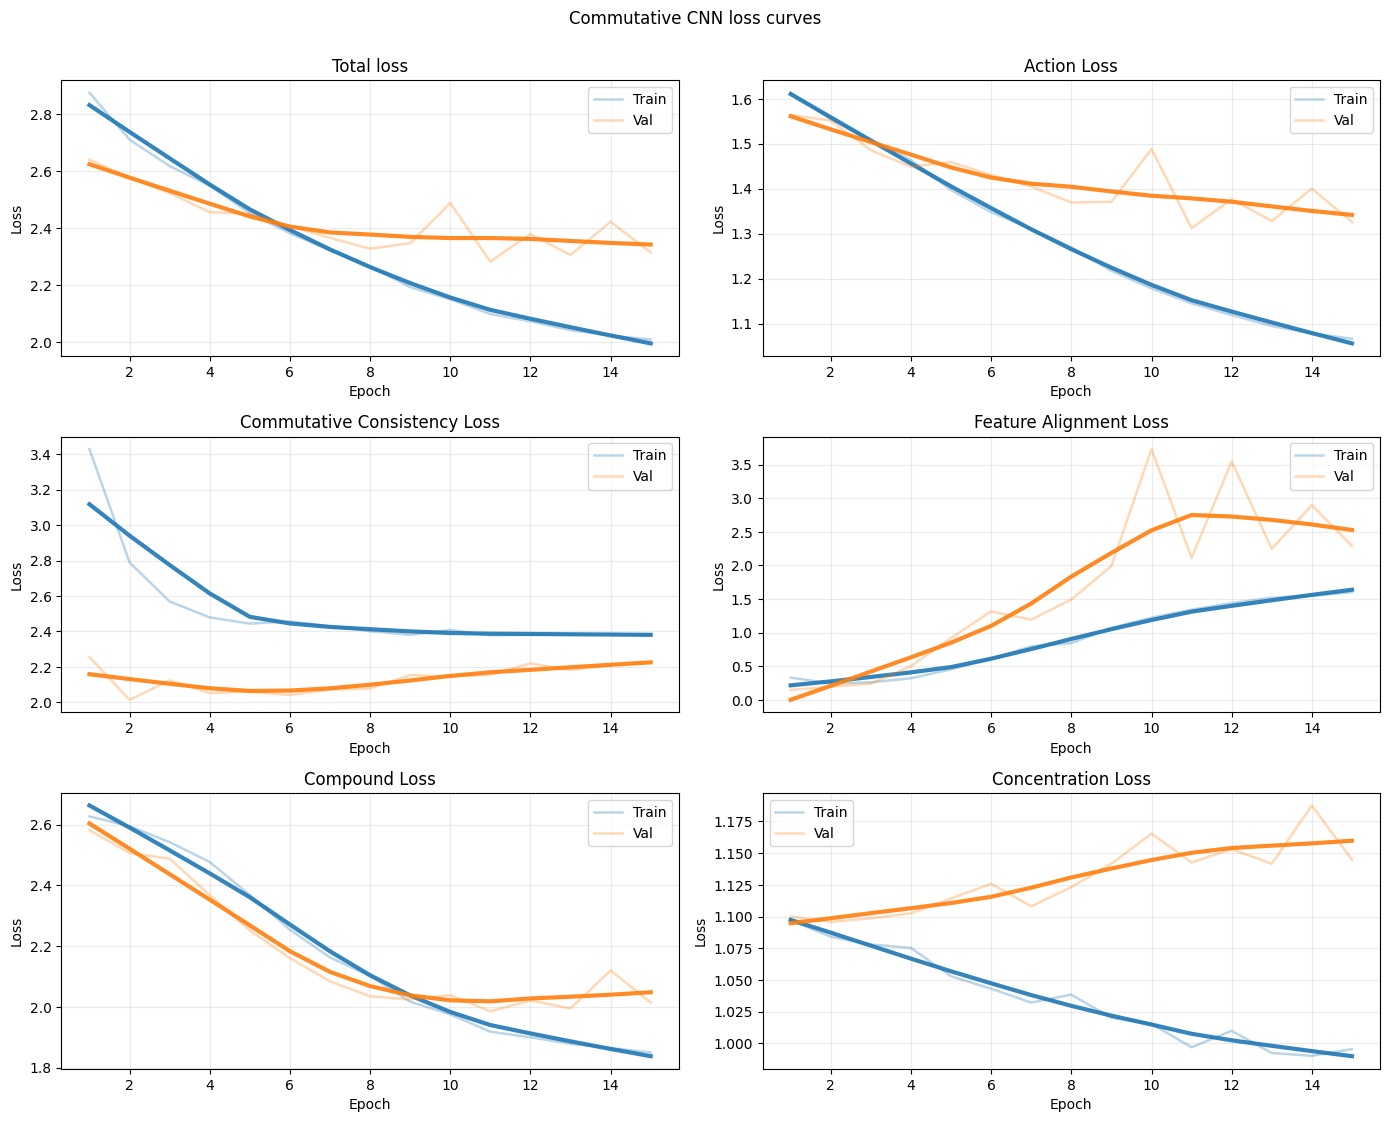

In [9]:
plot_training_history(model, title="Commutative CNN loss curves", loess_frac=0.6);



## Holdout report: action


,precision,recall,f1-score,support
class,,,,
Water,0.413043,0.791667,0.542857,24.0
GABAAR_Antagonist,0.600000,0.500000,0.545455,12.0
NMDAR_Activation,0.727273,0.800000,0.761905,10.0
AChE_Inhibitor_Reversible,0.000000,0.000000,0.000000,12.0
mAChR_Agonist_NonSelective,0.666667,0.166667,0.266667,12.0


,value
accuracy,0.500000
macro_precision,0.481397
macro_recall,0.451667
macro_f1,0.423377
weighted_precision,0.462654
weighted_recall,0.500000
weighted_f1,0.434187
n_samples,70.000000
roc_auc_ovr_macro,0.774736
average_precision_macro,0.526679


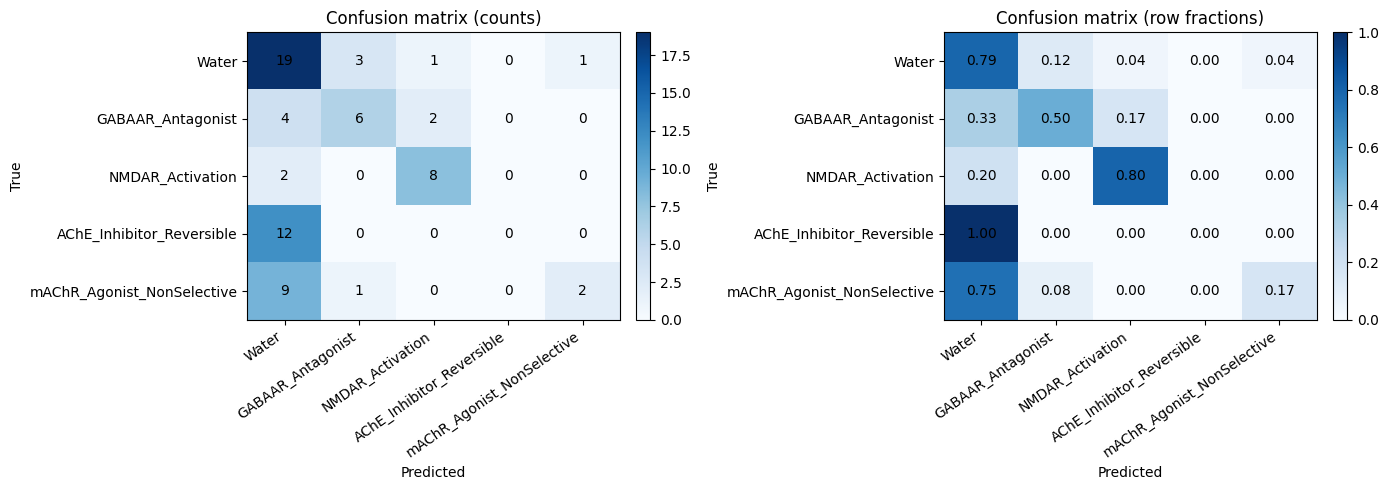


## Holdout report: compound


,precision,recall,f1-score,support
class,,,,
Control,0.381818,0.875,0.531646,24.0
Bemegride,0.000000,0.000,0.000000,6.0
Bicuculline,0.000000,0.000,0.000000,3.0
Gabazine,0.000000,0.000,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,0.300000,1.000,0.461538,3.0
Cis-ACPD,0.000000,0.000,0.000000,3.0
N-methyl-D-aspartate,0.500000,0.250,0.333333,4.0
Donepezil,0.000000,0.000,0.000000,4.0
Galantamine,0.000000,0.000,0.000000,4.0


,value
accuracy,0.371429
macro_precision,0.129371
macro_recall,0.173077
macro_f1,0.117424
weighted_precision,0.229481
weighted_recall,0.371429
weighted_f1,0.243963
n_samples,70.000000
roc_auc_ovr_macro,0.751716
average_precision_macro,0.341846


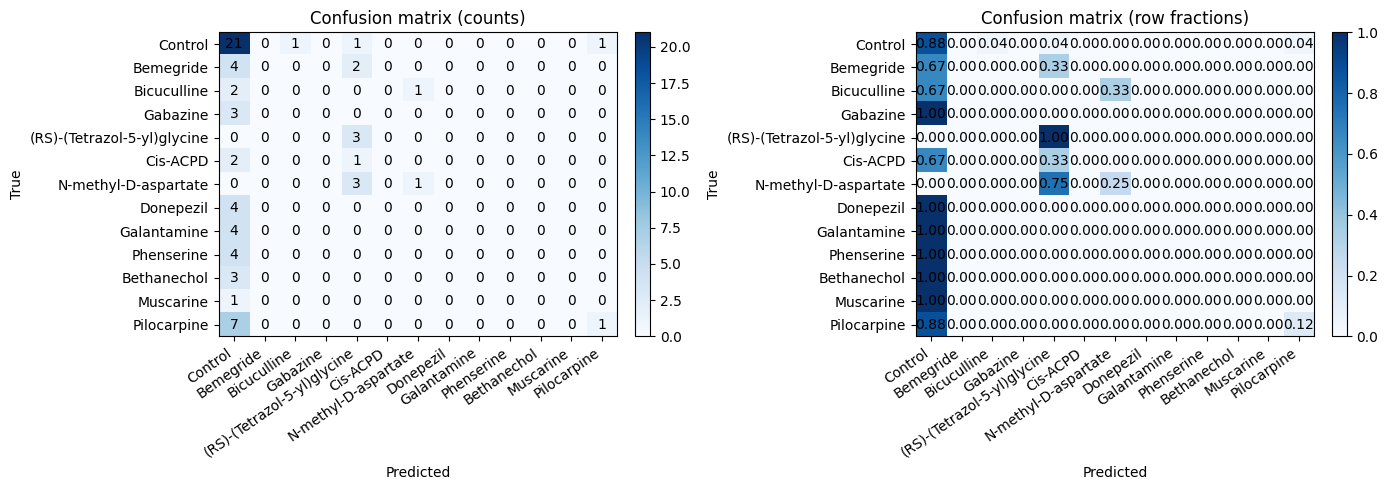


## Holdout report: concentration


,precision,recall,f1-score,support
class,,,,
control,0.408163,0.833333,0.547945,24.0
high,0.562500,0.360000,0.439024,25.0
mid,0.200000,0.047619,0.076923,21.0


,value
accuracy,0.428571
macro_precision,0.390221
macro_recall,0.413651
macro_f1,0.354631
weighted_precision,0.400835
weighted_recall,0.428571
weighted_f1,0.367738
n_samples,70.000000
roc_auc_ovr_macro,0.565534
average_precision_macro,0.418135


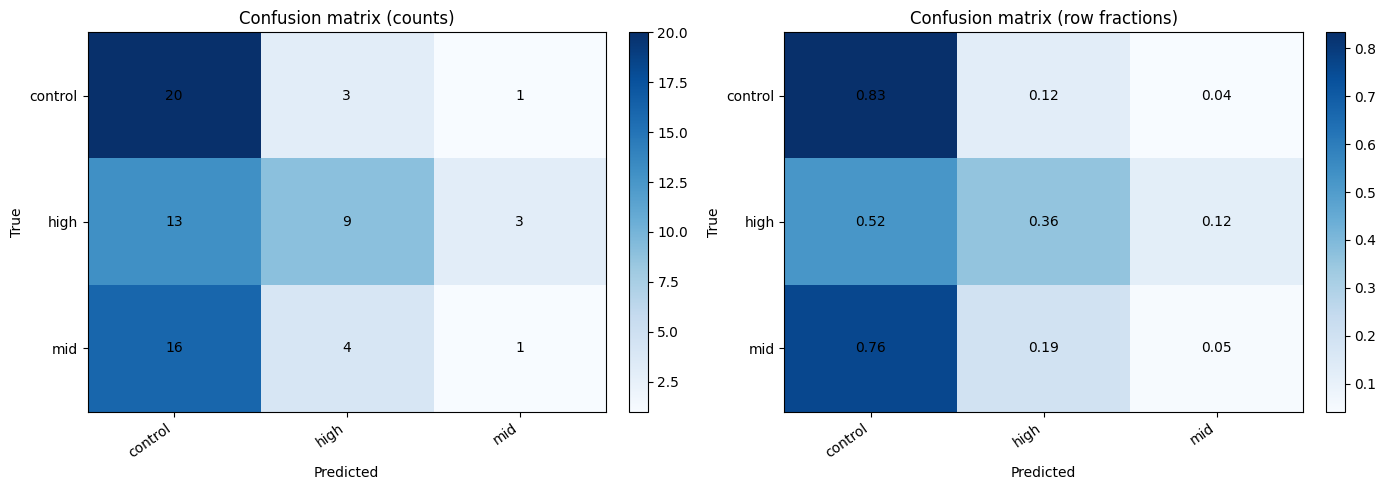

In [10]:
holdout_evaluation = display_holdout_evaluation(model, experiment)


/home/fabrizio/.venvs/py313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

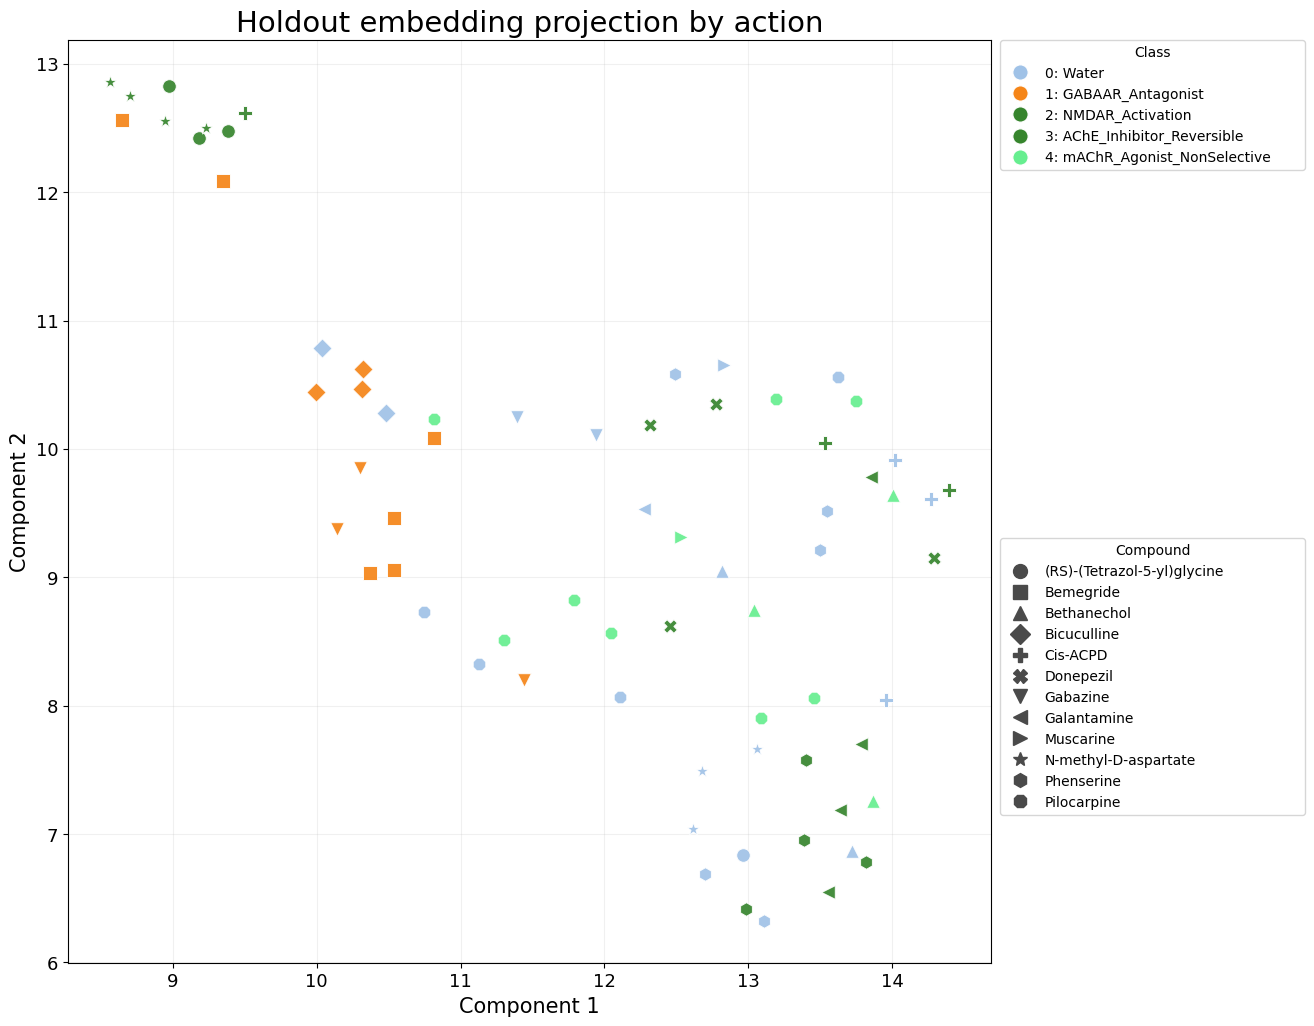

In [14]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)


In [12]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}


In [13]:
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
